/tmp/ipykernel_759/225899539.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_759/225899539.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("6H").last()
/tmp/ipykernel_759/225899539.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_759/225899539.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("6H").last()
/tmp/ipykernel_759/225899539.py:38: UserWarning: Could not infer

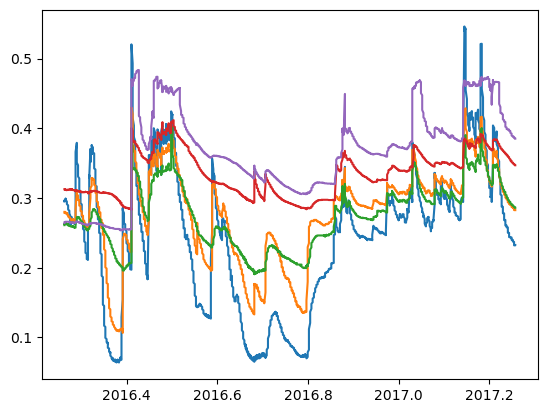

5


In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import os
import sys
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)
from pathlib import Path
home = Path.home()
subdir = home / "src" / "at-gpflow" / "experiments" / "soil-moisture" / "Wageningen" ## or whatever folder at-gpflow lives in
at_dir = home / "src" / "at-gpflow"


sys.path.append(str(at_dir))
sys.path.append(str(subdir))
BASE = str(subdir)

# Experiment 1: different substations using multiple depths
station_indices = ["04", "04", "01", "01"]
depths = [5, 10, 10, 20]
substations = []

# Experiment 2: different substations at the same depth
# station_indices = [f"0{d}" for d in range(1, 6)]
# depths = [5 for d in range(1, 6)]
# substations = []

# # Experiment 3: same substation, different depths
# station_indices = [f"15" for d in range(1, 6)]
# depths = [5, 10, 20, 40, 80]

substations = []
for station, depth in zip(station_indices, depths):

    source = pd.read_csv(BASE+f"/data/station_data/RM_SM_{station}_calibrated.csv")
    source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
    source.index = source["Measurement Time"]
    source = source.resample("6H").last()

    source['decimal_year'] = source['Measurement Time'].dt.year + (source['Measurement Time'].dt.dayofyear - 1) / 365.25
    source.index = source["decimal_year"]
    substations.append(source)

    plt.plot(source.index, source[f"{depth} cm VWC [m3/m3]"])
plt.show()

print(len(substations))


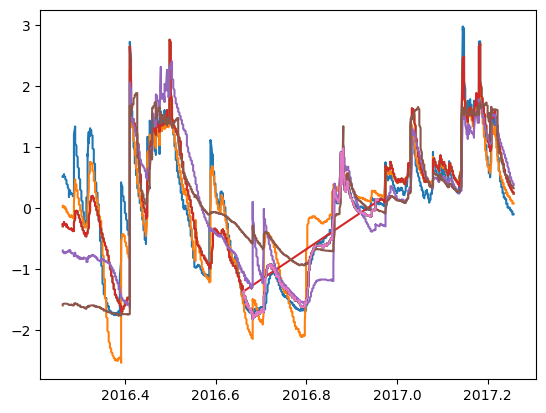

6848


In [5]:
condition_index = 2
data_X = []
data_Y = []

for i, (depth, data) in enumerate(zip(depths, substations)):
    Ay = data[f"{depth} cm VWC [m3/m3]"].to_numpy().reshape(-1, 1) 
    Ax = data.index.to_numpy().reshape(-1, 1)
    Ax = Ax[~np.isnan(Ay)].reshape(-1, 1)
    Ay = Ay[~np.isnan(Ay)].reshape(-1, 1)
    Ay = (Ay - Ay.mean()) / np.std(Ay)

    plt.plot(Ax, Ay)
    if i == condition_index:
        n_test = int(0.3*len(Ax))
        start = int(2*int(len(Ax))/5)
        end = start + n_test
        Xtest, ytest = Ax[start:end], Ay[start:end]
        Ax, Ay = np.concatenate((Ax[:start], Ax[end:])), np.concatenate((Ay[:start], Ay[end:]))
        plt.plot(Ax, Ay)
        plt.plot(Xtest, ytest, color="k")
    data_X.append(np.hstack((Ax, i*np.ones_like(Ax))))
    data_Y.append(np.hstack((Ay, i*np.ones_like(Ay))))

X = np.vstack(tuple(data_X))
y = np.vstack(tuple(data_Y))
plt.plot(Xtest, ytest)
plt.show()
print(len(X))

In [6]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

model1 = ConditionalMOGP((X, y), kernel=kern, conditioning_index=condition_index, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

gpf.utilities.print_summary(model1)
optimize(model1)
gpf.utilities.print_summary(model1)


/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model1.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model1.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤

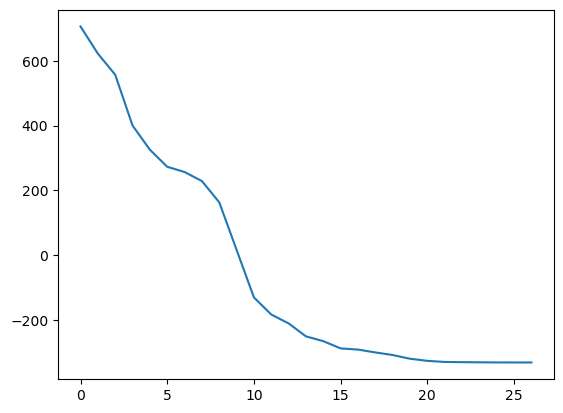

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0655606031809545                                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │

In [7]:
from atmodel import SparseCMOGP_QR, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 30 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind) 
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
model2 = SparseCMOGP((X, y), conditioning_index=condition_index, exact_target=False, kernel=kern, jitter=1e-4, inducing_variable=LMCInducingPointsBase(ivs), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True
#gpf.set_trainable(m.likelihood.source.variance, False)
#print(model2.conditional_likelihood(decompose_likelihood=True))

gpf.utilities.print_summary(model2)
optimize(model2)
gpf.utilities.print_summary(model2)

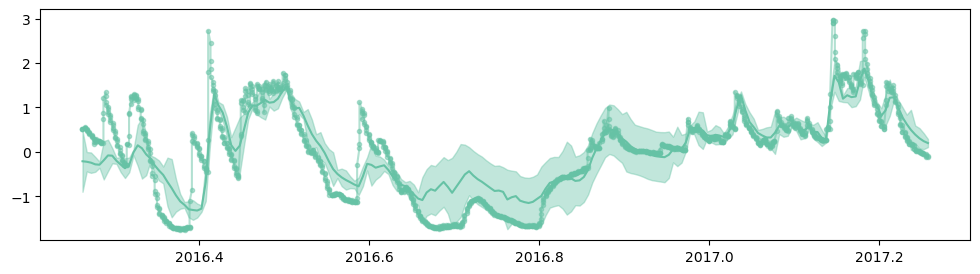

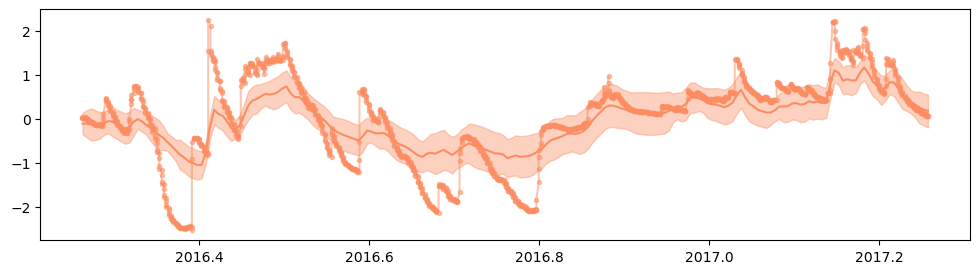

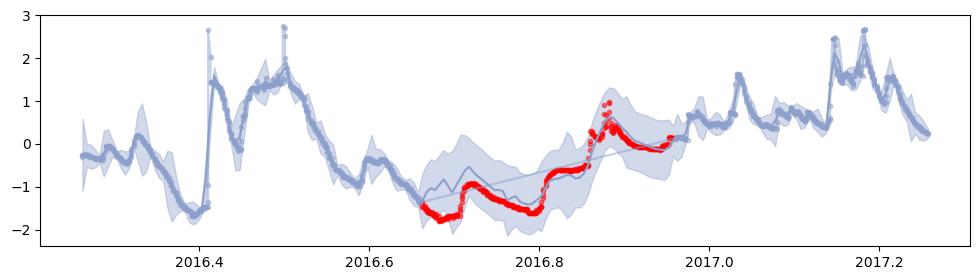

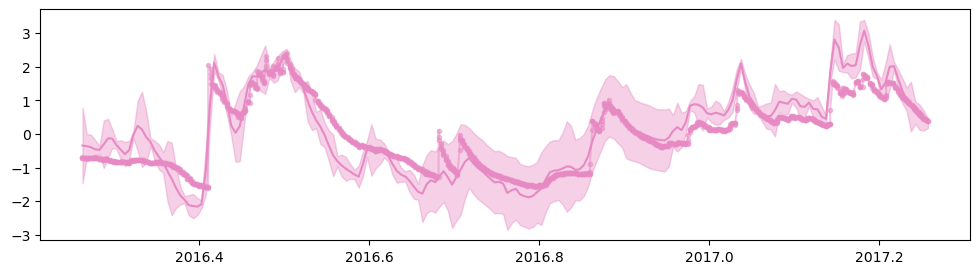

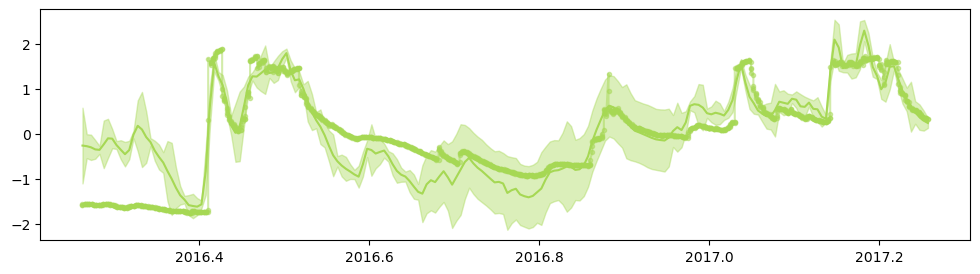

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0655606031809545                                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │

0.10176616161807743

In [8]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)
colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model2.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model2.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()
gpf.utilities.print_summary(model2)

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse

In [9]:
print(len(X))

6848


In [10]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 30 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

l1 = gpf.likelihoods.Gaussian()
l2 = gpf.likelihoods.Gaussian()
lik = gpf.likelihoods.SwitchedLikelihood(
    [l1 if i != condition_index else l2 for i in range(output_dim)]
)
# now build the GP model as normal
model3 =  gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=LMCInducingPointsBase(ivs))


gpf.utilities.print_summary(model3)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model3.training_loss_closure((X, y)),
    model3.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(model3)

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                              │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 0.0655606031809545                                 │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()         

2026-09-21 18:25:02.375890: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-21 18:25:02.450625: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤═══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                 │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪═══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 0.00591366839174716                                   │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼───────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True      

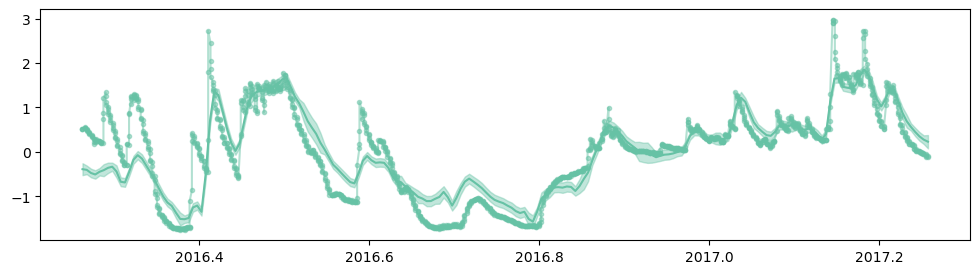

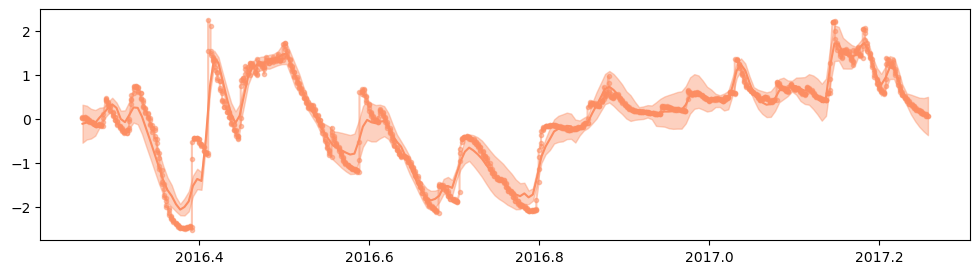

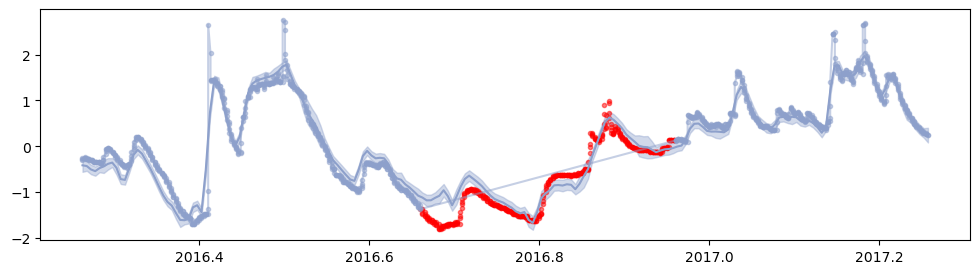

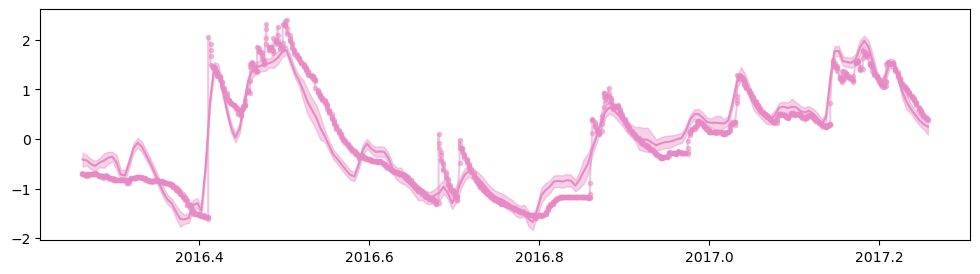

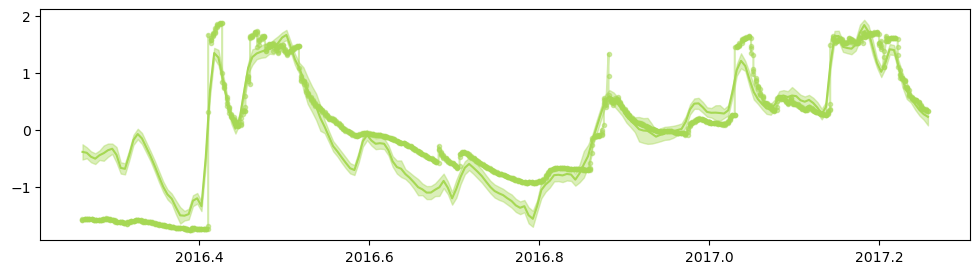

tf.Tensor(
[[-1.09304204]
 [-1.11376407]
 [-1.11376407]
 [-1.11376407]
 [-1.11376407]
 [-1.14610312]
 [-1.14610312]
 [-1.14610312]
 [-1.14610312]
 [-1.17955126]
 [-1.17955126]
 [-1.17955126]
 [-1.17955126]
 [-1.1884474 ]
 [-1.1884474 ]
 [-1.1884474 ]
 [-1.1884474 ]
 [-1.1648042 ]
 [-1.1648042 ]
 [-1.1648042 ]
 [-1.1648042 ]
 [-1.13265158]
 [-1.13265158]
 [-1.13265158]
 [-1.13265158]
 [-1.11289726]
 [-1.11289726]
 [-1.11289726]
 [-1.11289726]
 [-1.08936076]
 [-1.08936076]
 [-1.08936076]
 [-1.08936076]
 [-1.0326258 ]
 [-1.0326258 ]
 [-1.0326258 ]
 [-1.0326258 ]
 [-0.96275931]
 [-0.96275931]
 [-0.96275931]
 [-0.96275931]
 [-0.96333108]
 [-0.96333108]
 [-0.96333108]
 [-0.96333108]
 [-1.08795856]
 [-1.08795856]
 [-1.08795856]
 [-1.08795856]
 [-1.23782393]
 [-1.23782393]
 [-1.23782393]
 [-1.23782393]
 [-1.27870935]
 [-1.27870935]
 [-1.27870935]
 [-1.27870935]
 [-1.18946372]
 [-1.18946372]
 [-1.18946372]
 [-1.18946372]
 [-1.05166913]
 [-1.05166913]
 [-1.05166913]
 [-1.05166913]
 [-0.92920446]

0.07848715516514404

In [11]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model3.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model3.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

In [12]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

l1 = gpf.likelihoods.Gaussian()
l2 = gpf.likelihoods.Gaussian()
lik = gpf.likelihoods.SwitchedLikelihood(
    [l1 if i != condition_index else l2 for i in range(output_dim)]
)

# now build the GP model as normal
model4 =  gpf.models.GPRFITC((X, y), kernel=kern, likelihood=l1, inducing_variable=LMCInducingPointsBase(ivs))


gpf.utilities.print_summary(model4)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model4.training_loss,
    model4.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(model4)

╒════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                   │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ GPRFITC.kernel.kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.00591366839174716                                │
├────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ GPRFITC.kernel.kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.04449344307746384        

2026-09-21 18:27:12.182732: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-09-21 18:27:12.294865: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-09-21 18:27:12.385387: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-09-21 18:27:12.480784: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-09-21 18:27:12.575903: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

╒════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                   │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ GPRFITC.kernel.kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 5.26231                                            │
├────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ GPRFITC.kernel.kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.006974088720688126       

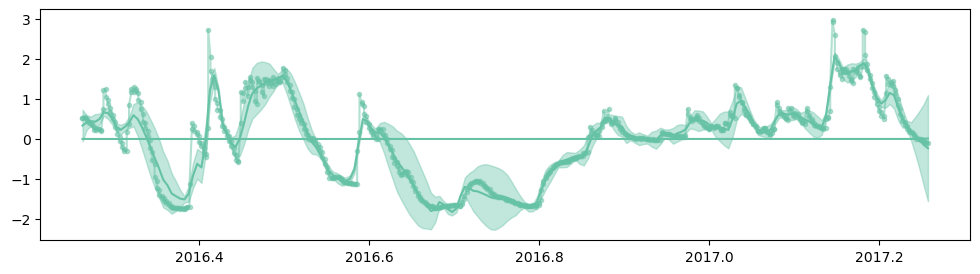

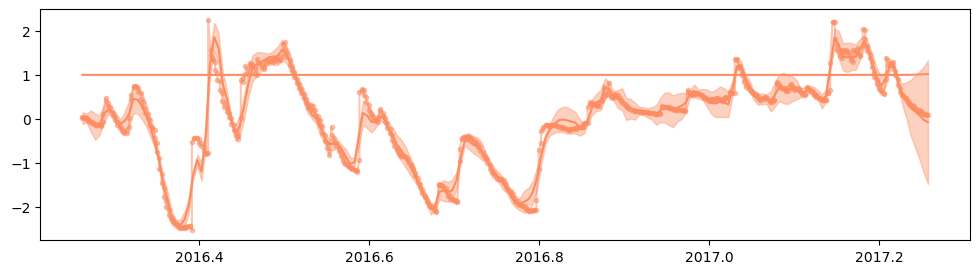

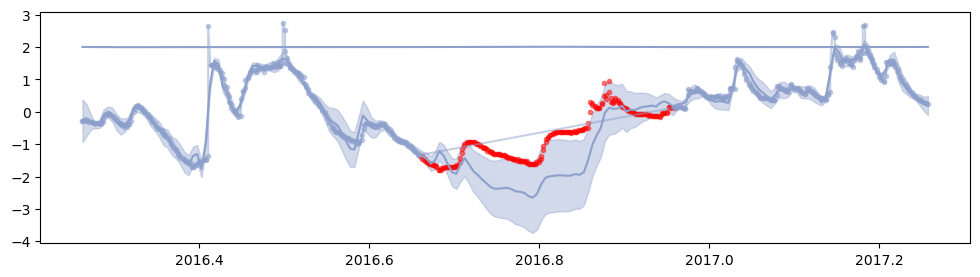

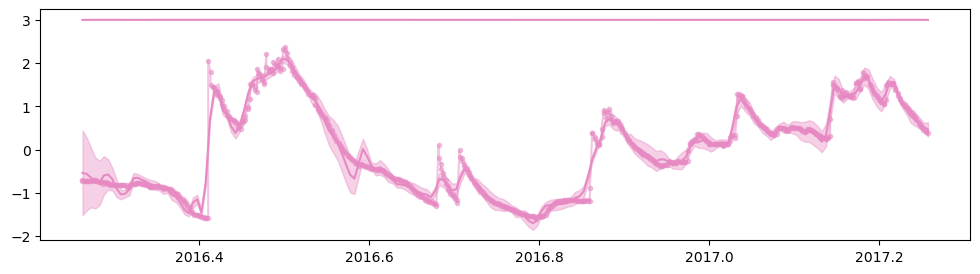

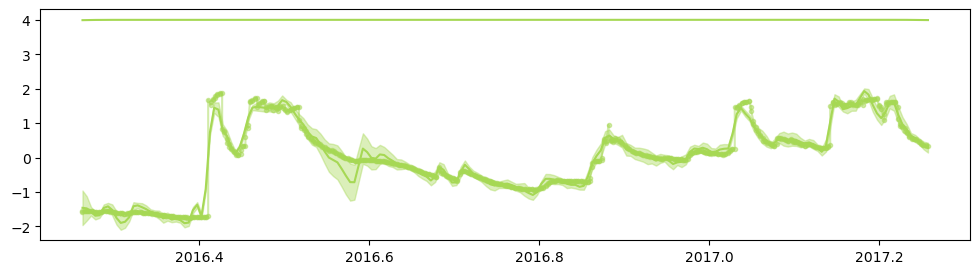

tf.Tensor(
[[-1.32781066  2.0004542 ]
 [-1.36792098  2.0006251 ]
 [-1.36792098  2.0006251 ]
 [-1.40010789  2.00083816]
 [-1.40010789  2.00083816]
 [-1.46666926  2.00104724]
 [-1.46666926  2.00104724]
 [-1.56083564  2.00124299]
 [-1.56083564  2.00124299]
 [-1.60323796  2.00144329]
 [-1.60323796  2.00144329]
 [-1.55917087  2.00165967]
 [-1.55917087  2.00165967]
 [-1.41189684  2.00189818]
 [-1.41189684  2.00189818]
 [-1.24360807  2.00215386]
 [-1.24360807  2.00215386]
 [-1.21620968  2.00238942]
 [-1.21620968  2.00238942]
 [-1.32882972  2.00262171]
 [-1.32882972  2.00262171]
 [-1.48489121  2.00287219]
 [-1.48489121  2.00287219]
 [-1.61569667  2.0031688 ]
 [-1.61569667  2.0031688 ]
 [-1.75420743  2.00347552]
 [-1.75420743  2.00347552]
 [-1.88672418  2.00374537]
 [-1.88672418  2.00374537]
 [-1.95204458  2.00400869]
 [-1.95204458  2.00400869]
 [-1.88035797  2.0042811 ]
 [-1.88035797  2.0042811 ]
 [-1.69980707  2.00456335]
 [-1.69980707  2.00456335]
 [-1.52592189  2.00484939]
 [-1.52592189  2.

0.6943826513688575

In [11]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model4.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model4.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

0.10064404083044386
3311.6888913513662
1223.1984343886784


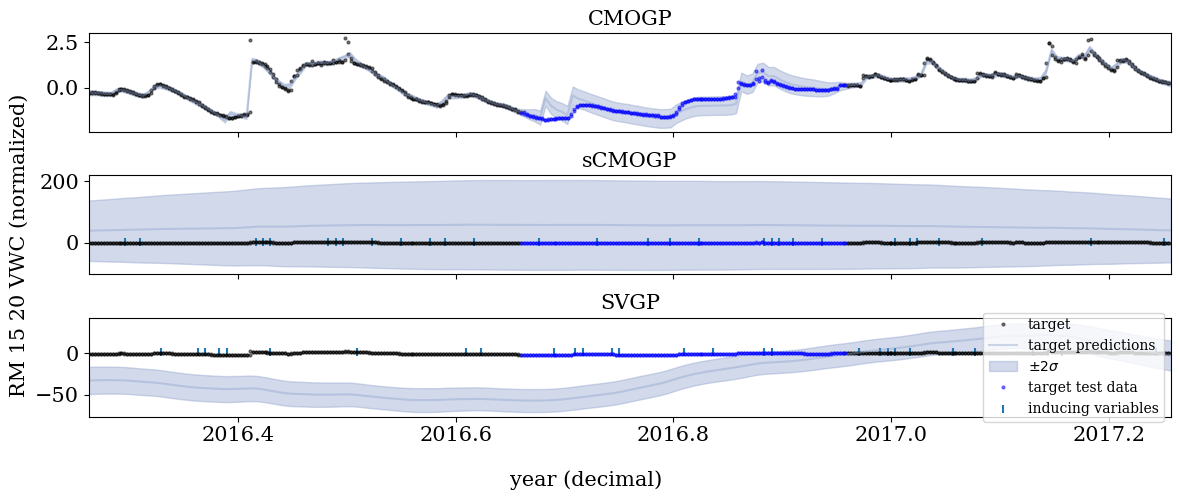

In [12]:
colors = color_sequences["Set2"]
plt.rcParams["font.family"] = "serif"
names = ["CMOGP", "sCMOGP", "SVGP"]
fig, ax = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
for i, model in enumerate([model1 ,model2, model3]):
    for index in [condition_index]:
        Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
        Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
        fmean, fvar = model.predict_f(Xplot)
        if index == condition_index:  
            fmean_test, fvar_test = model.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
            ax[i].plot(Ax[:,0], Ay[:,0], color="k", marker=".", lw=0, ms=4, alpha=0.5, label="target")
            ax[i].plot(Xplot[:,0], fmean, color=colors[index], alpha=0.4, label="target predictions")
            ax[i].fill_between(
                Xplot[:, 0],
                (fmean - 2 * np.sqrt(fvar))[:, 0],
                (fmean + 2 * np.sqrt(fvar))[:, 0],
                color=colors[index],
                alpha=0.4,
                label="$\pm 2\sigma$"
            )
            ax[i].set_xlim(np.min(Ax[:,0]), np.max(Ax[:,0]))
            ax[i].set_title(names[i], fontsize=15)
            fig.supxlabel("year (decimal)", fontsize=15)
            fig.supylabel(f"RM {station_indices[condition_index]} {depths[condition_index]} VWC (normalized)", fontsize=15)
            ax[i].tick_params(axis="both", labelsize=15)
            ax[i].plot(Xtest, ytest, "b.", ms=4, alpha=0.5, label="target test data")
            if i > 0: 
                ivs = model.inducing_variable.Z.numpy()
                ivs_target = ivs[ivs[:,1] == condition_index]
                ax[i].scatter(ivs_target, 2*np.ones_like(ivs_target), marker="|", label="inducing variables") 
            if i == 2:
                ax[i].legend(loc="right")

        mse = mean_squared_error(ytest, fmean_test[:,0])
        print(mse)
plt.tight_layout()
plt.show()